# Data Preparation

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 
  
# data (as pandas dataframes) 
X = statlog_german_credit_data.data.features 
y = statlog_german_credit_data.data.targets 


In [32]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Attribute1   1000 non-null   str  
 1   Attribute2   1000 non-null   int64
 2   Attribute3   1000 non-null   str  
 3   Attribute4   1000 non-null   str  
 4   Attribute5   1000 non-null   int64
 5   Attribute6   1000 non-null   str  
 6   Attribute7   1000 non-null   str  
 7   Attribute8   1000 non-null   int64
 8   Attribute9   1000 non-null   str  
 9   Attribute10  1000 non-null   str  
 10  Attribute11  1000 non-null   int64
 11  Attribute12  1000 non-null   str  
 12  Attribute13  1000 non-null   int64
 13  Attribute14  1000 non-null   str  
 14  Attribute15  1000 non-null   str  
 15  Attribute16  1000 non-null   int64
 16  Attribute17  1000 non-null   str  
 17  Attribute18  1000 non-null   int64
 18  Attribute19  1000 non-null   str  
 19  Attribute20  1000 non-null   str  
dtypes: int64(7), str(13)

In [33]:
y.value_counts()

class
0        700
1        300
Name: count, dtype: int64

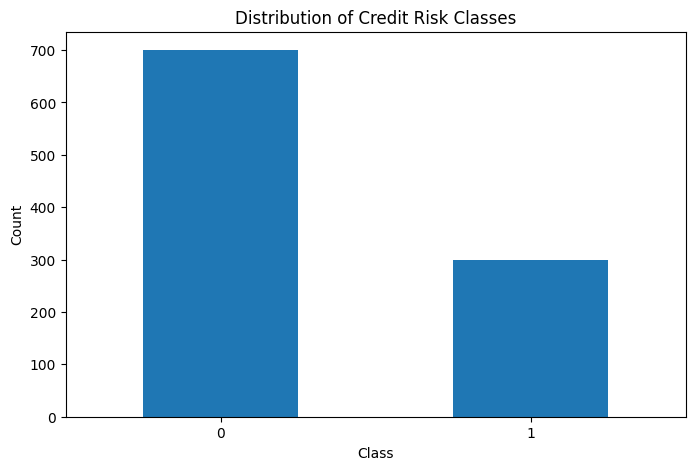

In [35]:
y['class'].value_counts().plot(kind='bar', figsize=(8, 5))
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Credit Risk Classes')
plt.xticks(rotation=0)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

y['class'] = y['class'].map({1: 0, 2: 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Transform Categorical into numeric features

In [4]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = X_train.select_dtypes(include=['str']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb = XGBClassifier()
xgb.fit(X_train_encoded, y_train.values.ravel())

#test set
y_pred_xgb = xgb.predict(X_test_encoded)
print("Test Set:\n",classification_report(y_test, y_pred_xgb))

y_proba_xgb = xgb.predict_proba(X_test_encoded)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))

Test Set:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82       141
           1       0.58      0.51      0.54        59

    accuracy                           0.74       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.74      0.74      0.74       200

ROC AUC Score: 0.7919221060223585


In [20]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier()
ada.fit(X_train_encoded, y_train.values.ravel())


y_pred_ada = ada.predict(X_test_encoded)
print("Test Set:\n",classification_report(y_test, y_pred_ada))

y_proba_ada = ada.predict_proba(X_test_encoded)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_ada))

Test Set:
               precision    recall  f1-score   support

           0       0.79      0.91      0.85       141
           1       0.67      0.41      0.51        59

    accuracy                           0.77       200
   macro avg       0.73      0.66      0.68       200
weighted avg       0.75      0.77      0.75       200

ROC AUC Score: 0.8137396321673278


In [28]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(verbose=-1, random_state=42, is_unbalance=True)
lgbm.fit(X_train_encoded, y_train.values.ravel())

y_pred_lgbm = lgbm.predict(X_test_encoded)
print("Test Set:\n",classification_report(y_test, y_pred_lgbm))

y_proba_lgbm = lgbm.predict_proba(X_test_encoded)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_lgbm))

Test Set:
               precision    recall  f1-score   support

           0       0.83      0.77      0.80       141
           1       0.54      0.63      0.58        59

    accuracy                           0.73       200
   macro avg       0.68      0.70      0.69       200
weighted avg       0.74      0.73      0.74       200

ROC AUC Score: 0.7942060343791322


/workspaces/practice_credit-risk/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/workspaces/practice_credit-risk/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [30]:
from catboost import CatBoostClassifier
catboost = CatBoostClassifier()
catboost.fit(X_train_encoded, y_train.values.ravel(), verbose=0)
y_pred_catboost = catboost.predict(X_test_encoded)
print("Test Set:\n",classification_report(y_test, y_pred_catboost))

y_proba_cat = catboost.predict_proba(X_test_encoded)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_cat))

Test Set:
               precision    recall  f1-score   support

           0       0.80      0.94      0.86       141
           1       0.76      0.42      0.54        59

    accuracy                           0.79       200
   macro avg       0.78      0.68      0.70       200
weighted avg       0.78      0.79      0.77       200

ROC AUC Score: 0.8249789638177666


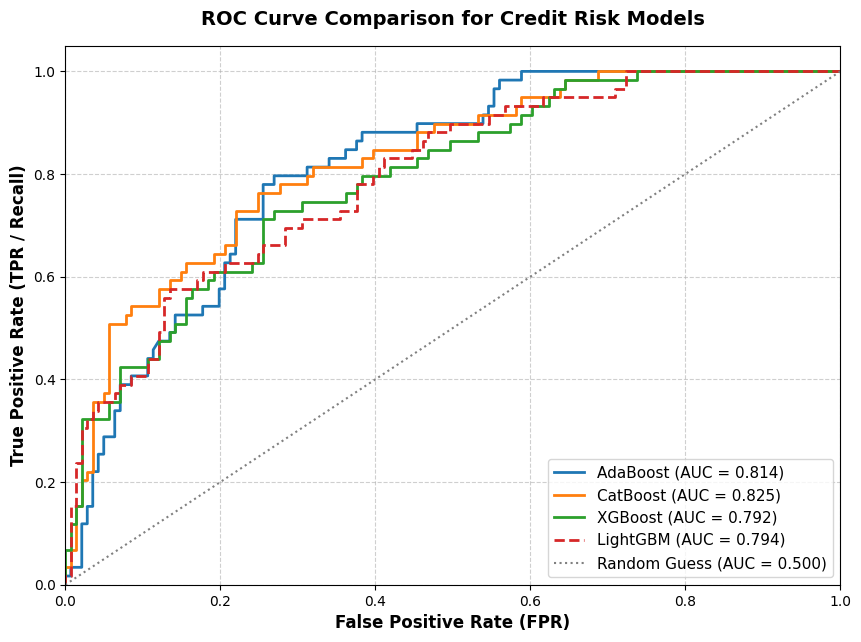

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score



fpr_ada, tpr_ada, _ = roc_curve(y_test, y_proba_ada)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_proba_cat)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgbm)

auc_ada = roc_auc_score(y_test, y_proba_ada)
auc_cat = roc_auc_score(y_test, y_proba_cat)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
auc_lgb = roc_auc_score(y_test, y_proba_lgbm)

# 5. Mulai proses pembuatan plot
plt.figure(figsize=(10, 7), facecolor='white')

# Plot kurva untuk masing-masing model
plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {auc_ada:.3f})', linewidth=2)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc_cat:.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', linewidth=2)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.3f})', linewidth=2, linestyle='--')

# Plot garis diagonal (Tebakan Acak / Baseline Minimum)
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Random Guess (AUC = 0.500)')

# Pengaturan Atribut Grafik (Sumbu, Judul, Legenda)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12, fontweight='bold')
plt.title('ROC Curve Comparison for Credit Risk Models', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()